In [5]:
!pip install pandas scikit-learn matplotlib

Training data (this is what makes it SUPERVISED learning:
every row has an input AND the correct answer/label):

     sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                  5.1               3.5                1.4               0.2   
1                  4.9               3.0                1.4               0.2   
2                  4.7               3.2                1.3               0.2   
3                  4.6               3.1                1.5               0.2   
4                  5.0               3.6                1.4               0.2   
..                 ...               ...                ...               ...   
145                6.7               3.0                5.2               2.3   
146                6.3               2.5                5.0               1.9   
147                6.5               3.0                5.2               2.0   
148                6.2               3.4                5.4               2.3

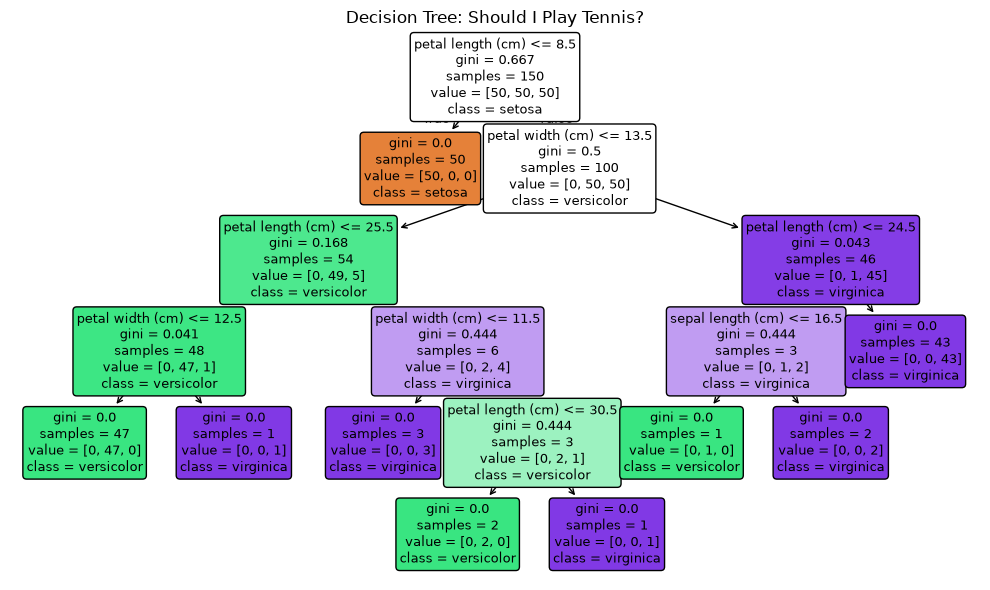

In [6]:
"""
Decision Tree Lab - Starter Code
=================================
Dataset: "Should I play tennis today?" (a classic tiny teaching dataset)
Each row is a PAST DAY with known weather conditions and whether tennis
was played. This is our LABELED training data -> supervised learning.

Fill in the TODOs. Estimated time: 10-12 minutes.
"""

import pandas as pd
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
from sklearn.preprocessing import OrdinalEncoder
from sklearn.datasets import load_iris 
import matplotlib.pyplot as plt

# -----------------------------------------------------------------
# 1. THE LABELED DATA
# -----------------------------------------------------------------
iris = load_iris()
data = pd.DataFrame(
    iris.data,
    columns=iris.feature_names
)
data["species"] = iris.target_names[iris.target]

print("Training data (this is what makes it SUPERVISED learning:")
print("every row has an input AND the correct answer/label):\n")
print(data)

# -----------------------------------------------------------------
# 2. TODO #1: Separate inputs (features) from the label (target)
# -----------------------------------------------------------------
# The model needs to learn a function: features -> label
# X = the columns the model is allowed to look at
# y = the column it's trying to predict
X = data.drop(columns=["species"])   # TODO: is this right? check it.
y = data["species"]                  # TODO: is this right? check it.

# Decision trees in sklearn need numbers, not text, so we encode.
encoder = OrdinalEncoder()
X_encoded = encoder.fit_transform(X)

# -----------------------------------------------------------------
# 3. TODO #2: Create and train ("fit") the model
# -----------------------------------------------------------------
# .fit(X, y) is the moment "learning" happens: the tree searches for
# the sequence of yes/no questions about X that best predicts y.
clf = DecisionTreeClassifier(max_depth=10, random_state=42)
clf.fit(X_encoded, y)          # TODO: call fit with the right arguments

# -----------------------------------------------------------------
# 4. Look at what it learned
# -----------------------------------------------------------------
feature_names = list(X.columns)
print("\nLearned decision rules:\n")
print(export_text(clf, feature_names=feature_names))

plt.figure(figsize=(10, 6))
plot_tree(clf, feature_names=feature_names, class_names=clf.classes_,
          filled=True, rounded=True, fontsize=9)
plt.title("Decision Tree: Should I Play Tennis?")
plt.tight_layout()
plt.savefig("tennis_tree.png", dpi=150)
print("\nSaved a picture of the tree to tennis_tree.png")

# -----------------------------------------------------------------
# 5. TODO #3: Predict on a NEW day the model has never seen
# -----------------------------------------------------------------
# This is the payoff of supervised learning: generalizing to new,
# unlabeled examples using the pattern learned from labeled ones.
new_flower = pd.DataFrame({
    "sepal length (cm)": [6],
    "sepal width (cm)": [3],
    "petal length (cm)": [5],
    "petal width (cm)": [2],
})
new_flower_encoded = encoder.transform(new_flower)
prediction = clf.predict(new_flower_encoded)

print(f"\nNew flower: {new_flower.to_dict(orient='records')[0]}")
print(f"Prediction: species = {prediction[0]}")

# -----------------------------------------------------------------
# 6. STRETCH GOAL (if time remains)
# -----------------------------------------------------------------
# Try changing max_depth to 1, then to 10. Re-run and compare the
# tree diagrams and the training accuracy. What happens? Why?
# accuracy = clf.score(X_encoded, y)
# print(f"Training accuracy: {accuracy:.2%}")